# Zel'dovich analysis

## Physical analysis

In [36]:
import yt   # library to upload and analyze AMR
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from unyt import Mpc, km, s, K, g, cm   # quokka works in cgs, but it is convenient to work with meaningful units

#### Physical parameters

In [50]:
# Physical paramters
h = 0.7
H0 = (h * 100.0 * km / s / Mpc).to('1/s')   # convesion in 1/s
a_init = 0.02                               # initial condition for the scale factor

#### Recover the scale factor 

In an Einstein-de Sitter (EdS) universe

$$t \propto a^{3/2}$$

At $z=49$ the universe is already a few million years old. t_init calculates the age of the universe at $a=0.02$. Adding t_sim, we get the absolute time since the beginning of the Big Bang, which is needed to calculate the correct scale factor $a$ for each plotfile.

In [51]:
def get_a(t_sim):
    t_init = (2.0/3.0) * (1.0/H0) * (a_init**1.5)     # age of the universe at a=0.02 (z=49)
    t_abs = t_sim + t_init                            # time from the BB in the simulation
    return (1.5 * H0 * t_abs)**(2.0/3.0)              # scale factor for each time of the simulation


# Import the plotfile

path = '/data/mfulghieri/quokka/outputs/ZeldovichPancake_11329/plt0000325'   # final plotfile

# create the dataset
ds = yt.load(path)

yt : [INFO     ] 2026-03-08 16:42:48,880 Parameters: current_time              = 1.0306896728772901e+17
yt : [INFO     ] 2026-03-08 16:42:48,880 Parameters: domain_dimensions         = [128   8   8]
yt : [INFO     ] 2026-03-08 16:42:48,881 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-03-08 16:42:48,881 Parameters: domain_right_edge         = [6.172e+25 3.086e+24 3.086e+24]


#### Importation of the plotfiles

In [52]:
# path of the directory containg the outputs
dir_path = "/data/mfulghieri/quokka/outputs/ZeldovichPancake_11329"

# os.path.join(output_dir, "plt*") search in the folder all files or folders that start with the name plt
# glob.glob(...) scans the folder and returns a list of all paths found that match the description (e.g. plt00000, plt00100, etc.)
# sorted(...) sorts the filenames alphabetically/numerically
plotfiles = sorted(glob.glob(os.path.join(dir_path, "plt*")))

# check
if not plotfiles:  # checks whether the plotfiles list is empty. An empty list is considered "False." 
    print("Error: no plotfile found!")
    exit(1)        # stop

#### Upload, sampling and visualize

yt : [INFO     ] 2026-03-08 17:14:32,196 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-03-08 17:14:32,196 Parameters: domain_dimensions         = [128   8   8]
yt : [INFO     ] 2026-03-08 17:14:32,197 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-03-08 17:14:32,197 Parameters: domain_right_edge         = [6.172e+25 3.086e+24 3.086e+24]
yt : [INFO     ] 2026-03-08 17:14:32,467 Parameters: current_time              = 918678317003743.8
yt : [INFO     ] 2026-03-08 17:14:32,468 Parameters: domain_dimensions         = [128   8   8]
yt : [INFO     ] 2026-03-08 17:14:32,469 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-03-08 17:14:32,469 Parameters: domain_right_edge         = [6.172e+25 3.086e+24 3.086e+24]
yt : [INFO     ] 2026-03-08 17:14:32,743 Parameters: current_time              = 2852716307426530.0
yt : [INFO     ] 2026-03-08 17:14:32,744 Parameters: domain_dimensions         = [128   8   8]
yt : [INFO     ] 2026

Analysis completed. Plots saved


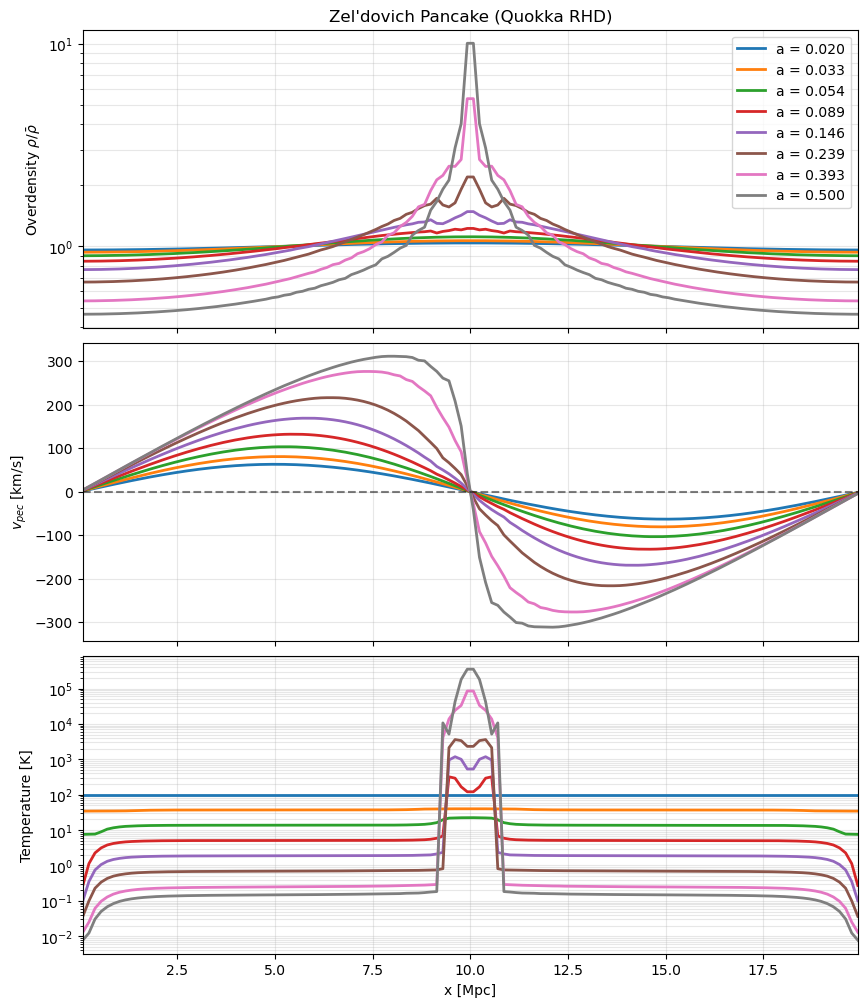

In [68]:
# Select some meaningful steps (e. g. start, half, end)
#indices = [0, len(plotfiles)//2, len(plotfiles)-1]   # // rounds the division to the closest integer
#selected_files = [plotfiles[i] for i in indices]

# Setup of the figures
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
plt.subplots_adjust(hspace=0.05)

for plt_file in plotfiles:                 # loop over the list of the files plotfiles
    ds = yt.load(plt_file)                 # load the dataset and read the metadata of the plotfiles
    a = get_a(ds.current_time).value       # .value extract a pure number (without the units of measure, for the plot title)
    
    # 1D data extraction
    ad = ds.all_data()  # creation of the object ad cointaining all the data
    
    # creation of a ray: a sampling line (way to analyze 1D problem in a 3D grid)
    left_edge = ds.domain_left_edge       # get the the left edge of the box (the origin)
    right_edge = ds.domain_right_edge
    # the ray starts from the origin (left edge), arrives at a point that has the same final X coordinate (right_edge[0]),
    # but which passes exactly through the center of the box (domain_center) in the Y and Z directions
    ray = ds.ray(left_edge, [right_edge[0], ds.domain_center[1], ds.domain_center[2]]) 
    
    sort_idx = np.argsort(ray['x']) # yt return the cell data not order, but according to the processor distribution -> space rearrangement of the data before plot 
    x_mpc = ray['x'][sort_idx].to('Mpc').value  # sort the x coordinates and convert to Mpc

   # Saved data (from print(ds.field_list)):
   # [('boxlib', 'gasDensity'), ('boxlib', 'gasEnergy'), ('boxlib', 'gasInternalEnergy'), ('boxlib', 'x-GasMomentum'), ('boxlib', 'y-GasMomentum'), ('boxlib', 'z-GasMomentum')]

    
    # 1. Density (Overdensity)
    rho = ray[('boxlib', 'gasDensity')][sort_idx]
    rho_mean = np.mean(rho)
    overdensity = (rho / rho_mean).value
    
    # 2. Peculiar velocity (v_phys / a): motion of the gas relative to the moving grid (the collapse)
    x_mom = ray[('boxlib', 'x-GasMomentum')][sort_idx]
    v_pec = (x_mom / rho).to('km/s').value
    
    # 3. Temperature
    e_int = ray[('boxlib', 'gasInternalEnergy')][sort_idx]
    gamma = 5.0/3.0
    mu = 1.0  # assuming only hydrogen for the pancake
    m_u = 1.660539e-24 * g
    k_B = 1.380649e-16 * (g * cm**2 / (s**2 * K))
    
    # Note: e_int in Quokka is energy density (erg/cm^3 comoving)
    # rho is mass density (g/cm^3 comoving)
    temp = (e_int * (gamma - 1) * mu * m_u) / (rho * k_B)
    temp = temp.to('K').value

    # --- Plotting ---
    label = f"a = {a:.3f}"
    axes[0].plot(x_mpc, overdensity, label=label, lw=2)
    axes[1].plot(x_mpc, v_pec, lw=2)
    axes[2].plot(x_mpc, temp, lw=2)
    

# --- plot refinement ---
axes[0].set_ylabel(r"Overdensity $\rho / \bar{\rho}$")
axes[0].set_yscale('log')
axes[0].legend(loc='upper right')
axes[0].set_title("Zel'dovich Pancake (Quokka RHD)")

axes[1].set_ylabel(r"$v_{pec}$ [km/s]")
axes[1].axhline(0, color='black', ls='--', alpha=0.5) # reference for the collapse

axes[2].set_ylabel("Temperature [K]")
axes[2].set_yscale('log')
axes[2].set_xlabel("x [Mpc]")

for ax in axes:
    ax.grid(True, which='both', alpha=0.3)   # grid both for the principal lines (major ticks) and secondary ones (minor ticks)
    ax.set_xlim(x_mpc.min(), x_mpc.max())

plt.savefig("/data/mfulghieri/quokka/outputs/ZeldovichPancake_11329/pancake_physics_stack.png", dpi=300) # 300 dots per inch. This is the standard for editorial quality, ensuring that text and lines are sharp and not "grainy."
print(f"Analysis completed. Plots saved")

### Density investigation

yt : [INFO     ] 2026-03-08 17:04:57,008 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-03-08 17:04:57,008 Parameters: domain_dimensions         = [128   8   8]
yt : [INFO     ] 2026-03-08 17:04:57,009 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-03-08 17:04:57,009 Parameters: domain_right_edge         = [6.172e+25 3.086e+24 3.086e+24]
yt : [INFO     ] 2026-03-08 17:04:57,574 Parameters: current_time              = 918678317003743.8
yt : [INFO     ] 2026-03-08 17:04:57,574 Parameters: domain_dimensions         = [128   8   8]
yt : [INFO     ] 2026-03-08 17:04:57,575 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-03-08 17:04:57,575 Parameters: domain_right_edge         = [6.172e+25 3.086e+24 3.086e+24]


File: plt0000000, t = 0.00e+00 s, a = 0.020, rho_max/rho_min = 1.08 dimensionless


yt : [INFO     ] 2026-03-08 17:04:57,853 Parameters: current_time              = 2852716307426530.0
yt : [INFO     ] 2026-03-08 17:04:57,854 Parameters: domain_dimensions         = [128   8   8]
yt : [INFO     ] 2026-03-08 17:04:57,854 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-03-08 17:04:57,854 Parameters: domain_right_edge         = [6.172e+25 3.086e+24 3.086e+24]


File: plt0000050, t = 9.19e+14 s, a = 0.033, rho_max/rho_min = 1.14 dimensionless


yt : [INFO     ] 2026-03-08 17:04:58,129 Parameters: current_time              = 6924329710253108.0
yt : [INFO     ] 2026-03-08 17:04:58,130 Parameters: domain_dimensions         = [128   8   8]
yt : [INFO     ] 2026-03-08 17:04:58,130 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-03-08 17:04:58,130 Parameters: domain_right_edge         = [6.172e+25 3.086e+24 3.086e+24]


...

File: plt0000200, t = 1.55e+16 s, a = 0.146, rho_max/rho_min = 1.93 dimensionless


yt : [INFO     ] 2026-03-08 17:04:58,948 Parameters: current_time              = 7.153174144341368e+16
yt : [INFO     ] 2026-03-08 17:04:58,949 Parameters: domain_dimensions         = [128   8   8]
yt : [INFO     ] 2026-03-08 17:04:58,949 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-03-08 17:04:58,949 Parameters: domain_right_edge         = [6.172e+25 3.086e+24 3.086e+24]


File: plt0000250, t = 3.35e+16 s, a = 0.239, rho_max/rho_min = 3.30 dimensionless


yt : [INFO     ] 2026-03-08 17:04:59,218 Parameters: current_time              = 1.0306896728772901e+17
yt : [INFO     ] 2026-03-08 17:04:59,219 Parameters: domain_dimensions         = [128   8   8]
yt : [INFO     ] 2026-03-08 17:04:59,219 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-03-08 17:04:59,220 Parameters: domain_right_edge         = [6.172e+25 3.086e+24 3.086e+24]


File: plt0000300, t = 7.15e+16 s, a = 0.393, rho_max/rho_min = 9.93 dimensionless
File: plt0000325, t = 1.03e+17 s, a = 0.500, rho_max/rho_min = 21.67 dimensionless
Analysis complete. Saved plot to /data/mfulghieri/quokka/analysis/zeldovich_pancake/density_profiles.png


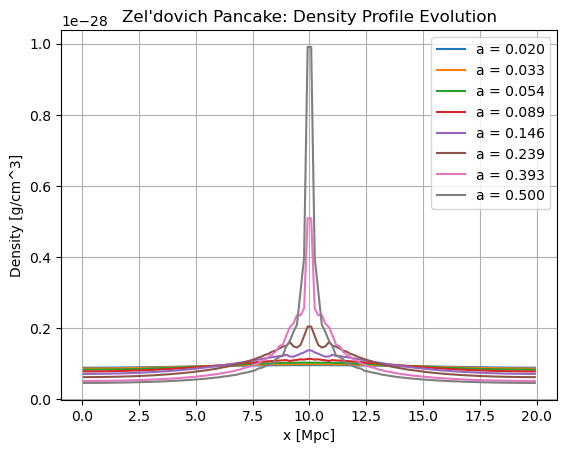

In [66]:
for plt_file in plotfiles:
    ds = yt.load(plt_file)
    t = ds.current_time.to('s')
    a = get_a(t).value
    
    # Get 1D profile along x-axis
    # We take a line through the center of the box
    left = ds.domain_left_edge
    right = ds.domain_right_edge
    center = (left + right) / 2.0
    
    # Create a ray along x
    ray = ds.ray(left, [right[0], center[1], center[2]])
    
    sort_idx = np.argsort(ray['x'])
    x = ray['x'][sort_idx].to('Mpc')
    rho = ray['boxlib', 'gasDensity'][sort_idx]
    
    rho_mean = np.mean(rho)
    delta = (rho / rho_mean) - 1.0
    
    plt.plot(x, rho, label=f"a = {a:.3f}")
    
    print(f"File: {os.path.basename(plt_file)}, t = {t:.2e}, a = {a:.3f}, rho_max/rho_min = {np.max(rho)/np.min(rho):.2f}")

plt.xlabel("x [Mpc]")
plt.ylabel("Density [g/cm^3]")
plt.title("Zel'dovich Pancake: Density Profile Evolution")
plt.legend()
plt.grid(True)
plt.savefig("/data/mfulghieri/quokka/outputs/ZeldovichPancake_11329/pancake_physics_stack.png", dpi=300)

print("Analysis complete. Saved plot to /data/mfulghieri/quokka/analysis/zeldovich_pancake/density_profiles.png")


## Inputs

### Zel'dovich Pancake simulation parameters
 ```
geometry.prob_lo     =  0.0  0.0  0.0                  # define the origin of the simulation box coordinates
geometry.prob_hi     =  6.172e25  3.086e24  3.086e24   # 20 Mpc x 1 Mpc x 1 Mpc (x, y, z) max extension
geometry.is_periodic = 1 1 1                           # periodic boundary conditions

amr.n_cell          = 128 8 8   # initial number of cells in each dimension
amr.max_level       = 0         # maximum level of refinement
amr.blocking_factor = 8         # factor by which the number of cells is multiplied at each level

quokka.bc = periodic periodic periodic   # boundary conditions for each dimension (x, y, z)
```

```
# Cosmology
cosmology.hubble_constant = 0.7
cosmology.omega_m         = 1.0         # Einstein-de Sitter universe
cosmology.omega_lambda    = 0.0
cosmology.a_init          = 0.02        # initial scale factor
```

```
# Poisson solver
poisson_abstol = 1.0e-45       # absolute tolerance for the Poisson solver (gravitational potential calculation)
poisson_reltol = 1.0e-10       # relative tolerance for the Poisson solver (gravitational potential calculation)
```

```
# Simulation control
plotfile_interval = 50          # interval between plotfiles: save a plotfile every 100 timesteps
amr.v = 1                       # verbosity level: 0=quiet, 1=verbose, 2=very verbose
do_subcycle = 0                 # whether to use subcycling
max_timesteps = 20000           # maximum number of timesteps: if the simulation runs for more than 20000 timesteps, it will stop
```


## Log analysis

### Inspection of the log file

1. **Initialization of AMReX,** with the module `amrex::Initialize`. Allocation of memory and read the .in file.

`AMReX (26.02-21-gbe8dfebe4bea) initialized
Successfully read inputs file ...`

2. Initialization of the **cosmological paramters** using the module `quokka::cosmology`. The inputs values are saved in the struct `CosmologyParams` of the file `Cosmology.hpp`.
   
   Defintion of an Einstein-de Sitter universe (matter only), with an initial scale factor $a_{init}=0.02$, corresponding to a redshift $z=49$.

``` 
  Cosmological parameters:
  H0      = 70.00000017 km/s/Mpc
  Omega_m = 1
  Omega_r = 0
  Omega_L = 0
  Omega_k = 0 (derived, 0 = flat)
  a_init  = 0.02 (z_init = 49) 
  ```

3. **Poisson solver** for $\nabla^2 \Phi = 4\pi G \rho_{comov}$, using the MLMG (Multi-Level Multi-Grid) algorithm: instead of solving the Poisson equation cell by cell (slow), the solver creates coarser grids, solves approximately the equation there, and then transfers the solution to the fine grid.

```
Creating new distribution map on level: 0
Gravity BCs: x:periodic y:periodic z:periodic 
Using MLMG solver with fully periodic boundaries...
```

The "rhs" (Right Hand Side) is the density of matter. The solver is calculating the gravitational potential $\Phi$ that will pull the gas toward the center of the pancake. The convergence to $10^{-46}$ is extremely precise thanks to the strict poisson_reltol parameters.

```
MLMG: Initial rhs = 1.576798909e-35
MLMG: Initial residual (resid0) = 1.576798909e-35
MLMG converged with final residual norm: 3.1770085e-46
```

4. **HD timestep**: Quokka calculates the CFL Condition ($dt < \Delta x / v_{signal}$): the signal velocity (fluid velocity + sound velocity) is about $3200$ km/s. The resulting timestep is huge ($10^{14}$ seconds, or millions of years) because the distances involved are cosmological (Mpc). Done with the module HydroSystem< problem_t >.

```
Coarse STEP 1 at t = 0 (0%) starts ...
...[level 0] estimated hydro timestep: 3.605875e+14
...[level 0] hydro timestep limited at cell (95, 7, 7) with signal speed = 3.209346e+08
...[level 0] cell density = 9.212945e-30, |v| = 6.300974e+06, cs = 1.177176e+05
...[level 0] timestep limited by HYDRO
...coarse timestep set by level 0
```

5. **Time advancement** with the Cosmology Half-Step, called  from applyCosmologyHalfStep. The momentum was reduced (Hubble Drag) and the gas cooled (Expansion Cooling).Then, Hydro Advance: The Euler equations were solved on 8192 cells. The gas began to move toward the center, attracted by the previously calculated gravity. Finally, Cosmology Half-Step: Second cosmology pass to complete the Strang Splitting. Done with the module QuokkaSimulation< problem_t >::advance.

```
[Level 0 step 1] ADVANCE with time = 0.0000000000e+00 dt = 1.2468020236e+13
[Level 0 step 1] Advanced 8192 cells
Gravity BCs: x:periodic y:periodic z:periodic 
Using MLMG solver with fully periodic boundaries...
```

6. **Second call of the gravity**. After hydrodynamics has displaced the gas, the density has changed. Quokka must recalculate gravity for the next step. 

```
MLMG: Initial rhs               = 1.576991706e-35
MLMG: Initial residual (resid0) = 1.576991706e-35
MLMG: Final Iter. 9 resid, resid/bnorm = 3.168154967e-46, 2.008986449e-11
MLMG: Timers: Solve = 0.007936888 Iter = 0.007725118 Bottom = 0.001957103
MLMG converged with final residual norm: 3.168154967e-46
```

7. **Last timestep**

```
Coarse STEP 325 at t = 1.026117634e+17 (99.55640978%) starts ...
...[level 0] estimated hydro timestep: 1.855892e+15
...[level 0] hydro timestep limited at cell (76, 4, 7) with signal speed = 6.235546e+07
...[level 0] cell density = 9.254158e-30, |v| = 3.108144e+07, cs = 4.729324e+03
...[level 0] timestep limited by HYDRO
...coarse timestep set by level 0
[Level 0 step 325] ADVANCE with time = 1.0261176343e+17 dt = 4.5720386023e+14
[Level 0 step 325] Advanced 8192 cells
Gravity BCs: x:periodic y:periodic z:periodic 
Using MLMG solver with fully periodic boundaries...

MLMG: Initial rhs               = 1.507769672e-34
MLMG: Initial residual (resid0) = 1.507769672e-34
MLMG: Final Iter. 9 resid, resid/bnorm = 1.119840304e-45, 7.427131111e-12
MLMG: Timers: Solve = 0.008702329 Iter = 0.008492593 Bottom = 0.00273911
MLMG converged with final residual norm: 1.119840304e-45


Simulation ended at t = 1.030689673e+17 (100%)
```

The signal speed has changed compared to step 1. The fluid velocity ($|v|$) is now the main actor ($\sim 31,000$ km/s!). The gas is falling into the pancake's gravity well. The speed of sound ($c_s$), however, is very low ($\sim 4.7$ km/s): the gas is cold and the flow is highly supersonic (Mach $\approx 6500$). The critical cell is $(76, 4, 7)$ where Quokka struggles the most to maintain stability (CFL).

### Final statistics

- The final scale factor obtained is $0.4999994$. The error compared to the expected 0.5 is on the order of a millionth part. This validates the evolveScaleFactor function and the integration of the Friedmann equation; the Density Ratio of 21.6 indicates that the structure has formed.

```
Zel'dovich Pancake Results:
  Final a = 0.499999407 (expected 0.5)
  rho_max / rho_min = 21.66575036
```

- The simulation lasted about 3.27 billion years:

$$\frac{1.030689673 \times 10^{17}}{3.15576 \times 10^7} \approx 3.266 \times 10^9 \text{ years}$$ 

```
Simulation ended at t = 1.030689673e+17 (100%)
```


- Performance:

FOM 13.4 microseconds to update a cell.
TinyProfiler: the simulation lasted about 36 seconds.

```
Performance figure-of-merit: 13.41181303 μs/zone-update
elapsed time: 35.87447885 seconds.
```

#### Mass

```
Initial gasDensity = 5.414239182e+45
	absolute conservation error = -2.40853614e+31
	relative conservation error = -4.448521869e-15
```

Mass is conserved to machine precision ($10^{-15}$)


#### Momentum

Orders of magnitude involved: 

- Energy of the system: $\sim 10^{60}$ erg.

- Mass of the system: $\sim 10^{45}$ g.

- Initial momentum at X: $8.6 \times 10^{35}$ g cm/s.


The total momentum of a periodic system must be zero. If the gas on the left moves to the right and the gas on the right moves to the left symmetrically, the total sum is zero.

The $10^{35}$ initial value is the numerical noise (zero minus a tiny fraction) of the initial condition. The relative error -51:  the relative error is calculated as $\frac{Final - Initial}{Initial}$. Starting with a number that is "almost zero" ($10^{35}$) and end with a number that is "a little less almost zero" ($10^{37}$), the ratio between the two becomes enormous. That -51 is telling that the numerical noise has changed 51 times since it started, but compared to the scale of the simulation ($10^{60}$), that value remains insignificant.

```
Initial x-GasMomentum = 8.63670966e+35
	absolute conservation error = -4.404721927e+37
	relative conservation error = -51

Initial y-GasMomentum = 0
	absolute conservation error = 3.988253945e+21

Initial z-GasMomentum = 0
	absolute conservation error = 4.507203465e+21
```

#### Energy


Energy is not conserved: the gas starts out almost still and very cold ($100K$). As the density sinusoid increases, gravity pulls the gas toward the center of the box. The gas "falls" into the gravitational well, converting potential energy into kinetic energy. Quokka log calculates the energy of the gas as $E_{gas} = E_{internal} + E_{kinetic}$ (without including the gravitational potential in the "conservation" calculation), sees a huge increase in kinetic energy that appears as "created". This is prominent over the lost of energy due to the expansion.


```
Initial gasEnergy = 5.381779216e+58
	absolute conservation error = 1.249311053e+60
	relative conservation error = 23.21371805

Initial gasInternalEnergy = 6.752472417e+55
	absolute conservation error = 4.98867458e+58
	relative conservation error = 738.7922929
```